In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [23]:
df = pd.read_csv("../data/clinical.tsv", sep="\t", low_memory=False)

print("Data loaded!")
print("Shape:", df.shape)

Data loaded!
Shape: (5546, 201)


In [24]:
df.head ()

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,1b884f21-eb24-467f-aba2-208af17070b9,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
1,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,27868bc3-23c8-5e85-a0e2-314e6cdf9b2a,Adjuvant,yes,Treatment Ongoing,'--,Hormone Therapy
2,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,aedf144c-6b7b-4d76-a3cb-4271aef10f1d,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
3,TCGA-BRCA,0045349c-69d9-4306-a403-c9c1fa836644,Informed Consent,76,'--,Adenomas and Adenocarcinomas,Diagnosis,'--,Breast,TCGA-A1-A0SB,...,'--,'--,'--,'--,0a534cae-de91-5e77-a3e7-b52d46bd3966,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
4,TCGA-BRCA,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,Informed Consent,19,'--,Adnexal and Skin Appendage Neoplasms,Diagnosis,No,Breast,TCGA-A2-A04W,...,'--,'--,'--,'--,024faa94-ec57-4d14-b919-62dcab409958,Adjuvant,yes,Treatment Ongoing,'--,Bisphosphonate Therapy


In [25]:
df.columns.tolist()

['project.project_id',
 'cases.case_id',
 'cases.consent_type',
 'cases.days_to_consent',
 'cases.days_to_lost_to_followup',
 'cases.disease_type',
 'cases.index_date',
 'cases.lost_to_followup',
 'cases.primary_site',
 'cases.submitter_id',
 'demographic.age_at_index',
 'demographic.age_is_obfuscated',
 'demographic.cause_of_death',
 'demographic.cause_of_death_source',
 'demographic.country_of_birth',
 'demographic.country_of_residence_at_enrollment',
 'demographic.days_to_birth',
 'demographic.days_to_death',
 'demographic.demographic_id',
 'demographic.education_level',
 'demographic.ethnicity',
 'demographic.gender',
 'demographic.marital_status',
 'demographic.occupation_duration_years',
 'demographic.population_group',
 'demographic.race',
 'demographic.sex_at_birth',
 'demographic.submitter_id',
 'demographic.vital_status',
 'demographic.year_of_birth',
 'demographic.year_of_death',
 'diagnoses.adrenal_hormone',
 'diagnoses.age_at_diagnosis',
 'diagnoses.ajcc_clinical_m',
 'dia

In [26]:
cols = [
    'cases.case_id',
    'demographic.age_at_index',
    'demographic.vital_status',
    'demographic.days_to_death',
    'diagnoses.ajcc_pathologic_stage',
    'diagnoses.age_at_diagnosis',
    'diagnoses.days_to_last_follow_up',
    'treatments.treatment_type',
    'treatments.treatment_outcome'
]

df = df[cols]
print("Selected columns!")
print(df.shape)
df.head()

Selected columns!
(5546, 9)


,cases.case_id,demographic.age_at_index,demographic.vital_status,demographic.days_to_death,diagnoses.ajcc_pathologic_stage,diagnoses.age_at_diagnosis,diagnoses.days_to_last_follow_up,treatments.treatment_type,treatments.treatment_outcome
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,60,Alive,'--,Stage IA,22279,337.0,"Radiation Therapy, NOS",'--
1,001cef41-ff86-4d3f-a140-a647ac4b10a1,60,Alive,'--,Stage IA,22279,337.0,Hormone Therapy,Treatment Ongoing
2,001cef41-ff86-4d3f-a140-a647ac4b10a1,60,Alive,'--,Stage IA,22279,337.0,"Surgery, NOS",'--
3,0045349c-69d9-4306-a403-c9c1fa836644,70,Alive,'--,Stage I,25833,259.0,"Surgery, NOS",'--
4,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,50,Alive,'--,Stage IIB,18345,3102.0,Bisphosphonate Therapy,Treatment Ongoing


In [27]:
df.replace("'--", None, inplace=True)

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
cases.case_id                          0
demographic.age_at_index               1
demographic.vital_status               1
demographic.days_to_death           4701
diagnoses.ajcc_pathologic_stage      568
diagnoses.age_at_diagnosis           194
diagnoses.days_to_last_follow_up     598
treatments.treatment_type             37
treatments.treatment_outcome        3877
dtype: int64


In [28]:
# Count how many times each patient ID appears
print("Patient ID value counts:")
print(df["cases.case_id"].value_counts().head(10))

Patient ID value counts:
cases.case_id
c07b122e-ac50-4db2-add2-5617a5d0e976    40
ccd4a24b-d8cc-4686-9dee-c98b0c5a8d21    33
a8e7d8a4-bbf0-496b-b387-8e014cfdcea6    22
deba32e4-0e68-4711-941b-3b63bd965afb    21
8d5fe6e8-d2cc-481f-a6a1-9cb6e7982cde    20
9435447e-d65f-408b-863b-6576b1d652dd    19
4a831893-f4ca-4357-a756-b5e954e35dd7    19
64f67506-f2df-4f0a-b7be-29b4949e986a    17
9ce7ce09-4409-4fa3-9f78-b2b24716f860    17
a4903de8-6cf5-4541-8ec7-065beace8b44    17
Name: count, dtype: int64


In [29]:
# Remove completely duplicate rows from the table
df = df.drop_duplicates()

# Drop rows where vital_status is missing (only 1 row, not useful to keep)
df = df.dropna(subset=["demographic.vital_status"])

# Convert age_at_index to a number so we can do maths on it
df["demographic.age_at_index"] = pd.to_numeric(df["demographic.age_at_index"], errors="coerce")

# Convert age_at_diagnosis to a number (currently stored as days)
df["diagnoses.age_at_diagnosis"] = pd.to_numeric(df["diagnoses.age_at_diagnosis"], errors="coerce")

# Convert days_to_death to a number
df["demographic.days_to_death"] = pd.to_numeric(df["demographic.days_to_death"], errors="coerce")

# Convert days_to_last_follow_up to a number
df["diagnoses.days_to_last_follow_up"] = pd.to_numeric(df["diagnoses.days_to_last_follow_up"], errors="coerce")

# Print confirmation and new shape of the table
print("Data Cleaned!")
print("New Shape:", df.shape)

Data Cleaned!
New Shape: (4233, 9)


In [30]:
# Create a patient-level table with one row per unique patient
df_patients = df.drop_duplicates(subset=["cases.case_id"], keep="first")

# Keep full table for treatment analysis
df_treatments = df.copy()

# Print both shapes to confirm
print("Patients table (one row per patient):", df_patients.shape)
print("Patients table (all treatments rows):", df_treatments.shape)

Patients table (one row per patient): (1097, 9)
Patients table (all treatments rows): (4233, 9)


In [31]:
# Show statistical summary of numerical columns in patient table
print("Statistical Summary of Patient Data:")
df_patients.describe()

Statistical Summary of Patient Data:


,demographic.age_at_index,demographic.days_to_death,diagnoses.age_at_diagnosis,diagnoses.days_to_last_follow_up
count,1097.000000,151.000000,1050.000000,991.000000
mean,58.450319,1584.615894,21603.077143,1187.786075
std,13.197045,1312.070221,4781.955812,1138.973009
min,26.000000,0.000000,9840.000000,-7.000000
25%,49.000000,613.000000,18047.750000,430.500000
50%,58.000000,1152.000000,21558.500000,792.000000
75%,67.000000,2322.000000,24845.250000,1611.500000
max,89.000000,7455.000000,32872.000000,8556.000000


In [32]:
# Remove rows where days_to_last_follow_up is negative (data error)
df_patients = df_patients[df_patients["diagnoses.days_to_last_follow_up"] >= 0]

print("Shape after removing negative follow up days:", df_patients.shape)

Shape after removing negative follow up days: (990, 9)


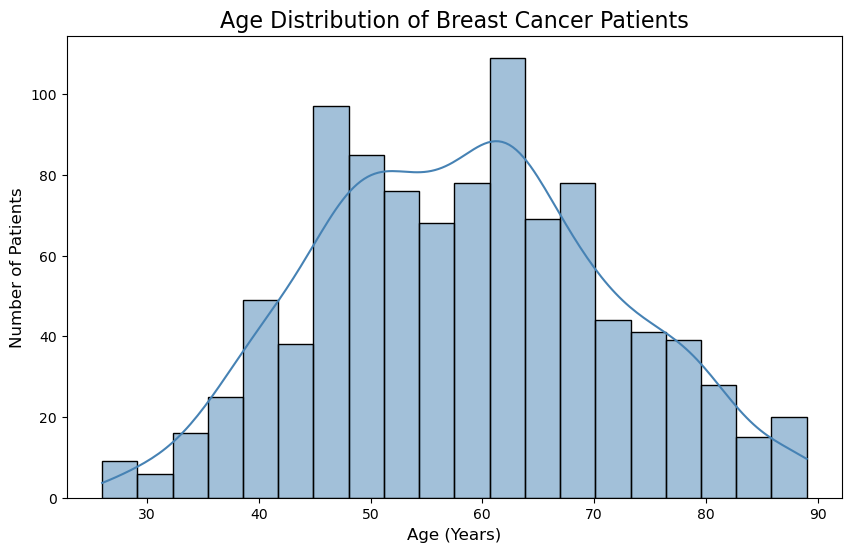

In [33]:
plt.figure(figsize=(10,6))

# Draw a histogram of patient ages with 20 bars
sns.histplot(df_patients["demographic.age_at_index"], bins=20, color="steelblue", kde=True)

plt.title("Age Distribution of Breast Cancer Patients", fontsize=16)
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.savefig('../images/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

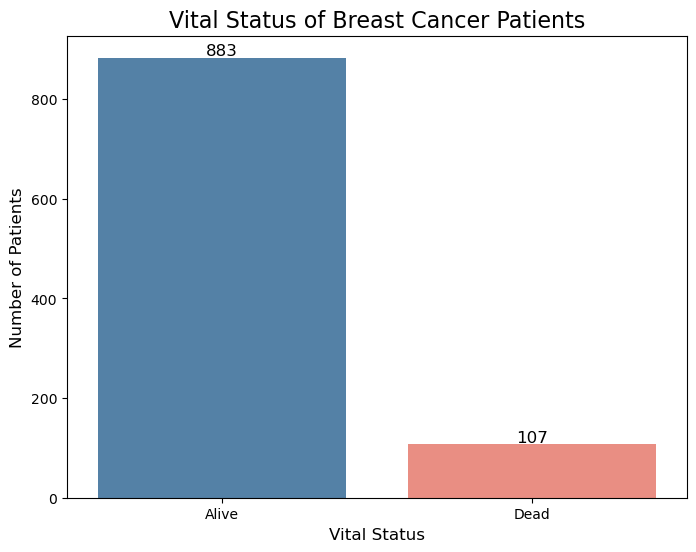

In [34]:
# Count how many patients are alive vs dead
vital_counts = df_patients["demographic.vital_status"].value_counts()

# Set the figure size
plt.figure(figsize=(8, 6))

# Draw a bar chart of vital status counts
sns.barplot(x=vital_counts.index, y=vital_counts.values, hue=vital_counts.index, palette=["steelblue","salmon"], legend=False)

plt.title("Vital Status of Breast Cancer Patients", fontsize=16)
plt.xlabel("Vital Status", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Add the exact number on top of each bar
for i, count in enumerate(vital_counts.values):
    plt.text(i, count + 5, str(count), ha="center", fontsize=12)

plt.savefig('../images/vital_status.png', dpi=150, bbox_inches='tight')
plt.show()

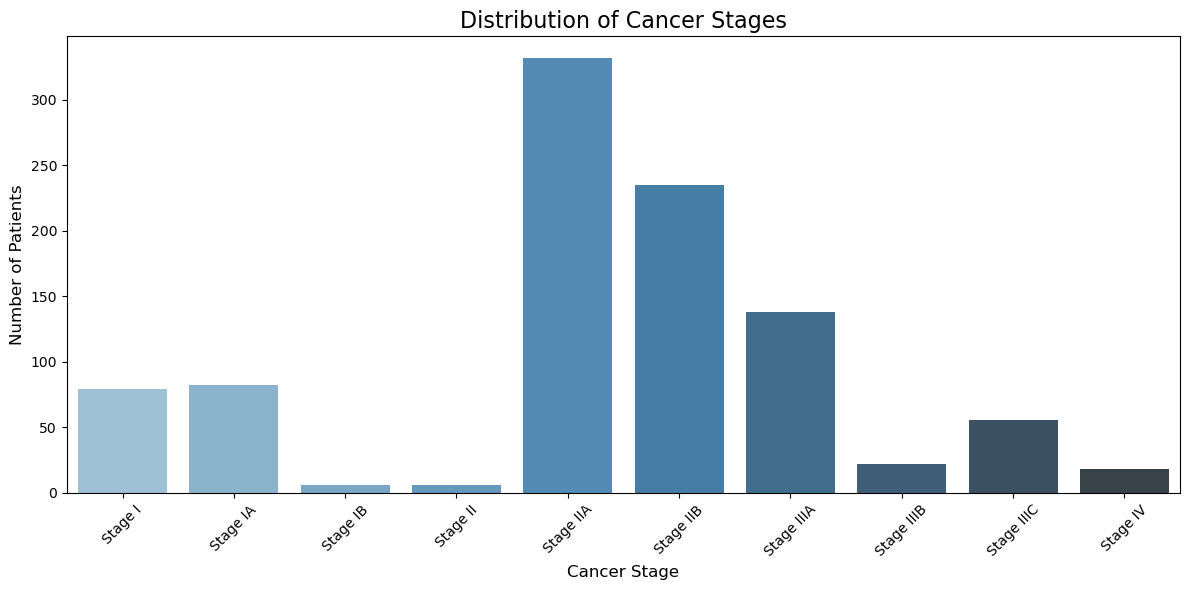

In [35]:
# Count how many patients are in each cancer stage
stage_counts = df_patients["diagnoses.ajcc_pathologic_stage"].value_counts()

stage_order = ['Stage I', 'Stage IA', 'Stage IB', 'Stage II', 'Stage IIA', 
               'Stage IIB', 'Stage III', 'Stage IIIA', 'Stage IIIB', 
               'Stage IIIC', 'Stage IV']

# Filter to only keep stages that exist in our data
stage_order = [s for s in stage_order if s in stage_counts.index]

plt.figure(figsize=(12,6))

# Draw a bar chart of cancer stages
sns.barplot(x=stage_order, y=stage_counts[stage_order], hue=stage_order, palette="Blues_d", legend=False)

plt.title("Distribution of Cancer Stages", fontsize=16)
plt.xlabel("Cancer Stage", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45)

# Display
plt.tight_layout()
plt.savefig('../images/cancer_stage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

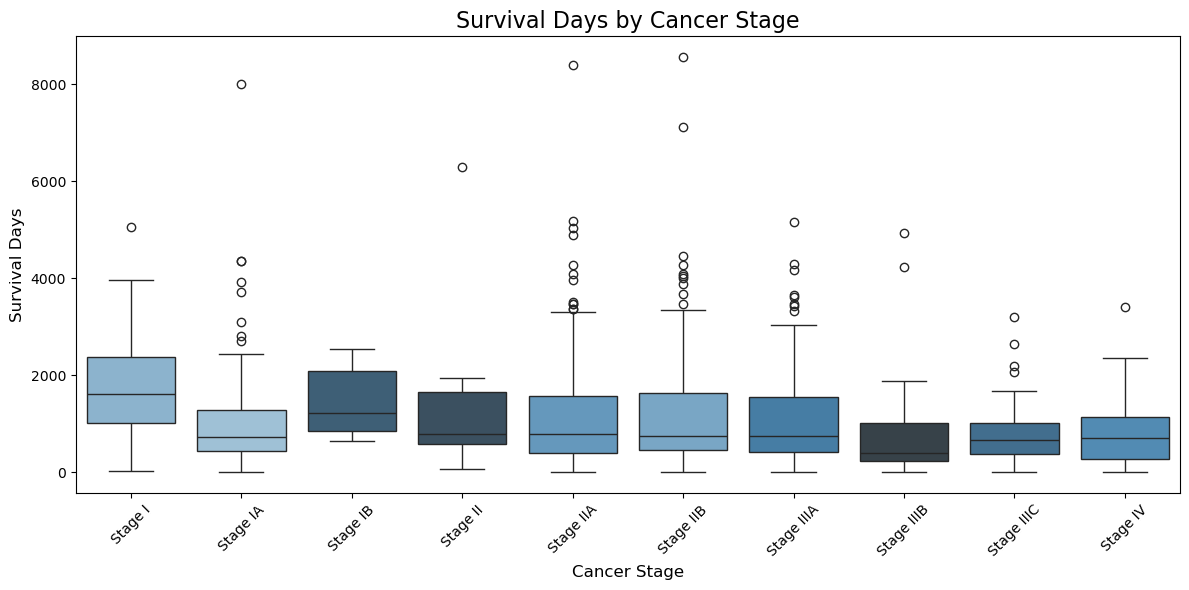

In [36]:
# Create a survival column - use days_to_death for dead patients, 
# days_to_last_follow_up for alive patients
df_patients["survival_days"] = df_patients["demographic.days_to_death"].fillna(df_patients["diagnoses.days_to_last_follow_up"])

# Filter to only keep our known stages in the right order
df_stage_survival = df_patients[df_patients["diagnoses.ajcc_pathologic_stage"].isin(stage_order)]

# Set figure size
plt.figure(figsize=(12,6))

# Draw a box plot of survival days by cancer stage
sns.boxplot(
    data=df_stage_survival,
    x="diagnoses.ajcc_pathologic_stage",
    y="survival_days",
    order=stage_order,
    hue="diagnoses.ajcc_pathologic_stage",
    palette="Blues_d",
    legend=False
)

# Add title and axis labels
plt.title("Survival Days by Cancer Stage", fontsize=16)
plt.xlabel("Cancer Stage", fontsize=12)
plt.ylabel("Survival Days", fontsize=12)

# Rotate x axis labels so they dont overlap
plt.xticks(rotation=45)

# Fix spacing so nothing gets cut off
plt.tight_layout()

plt.savefig('../images/survival_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

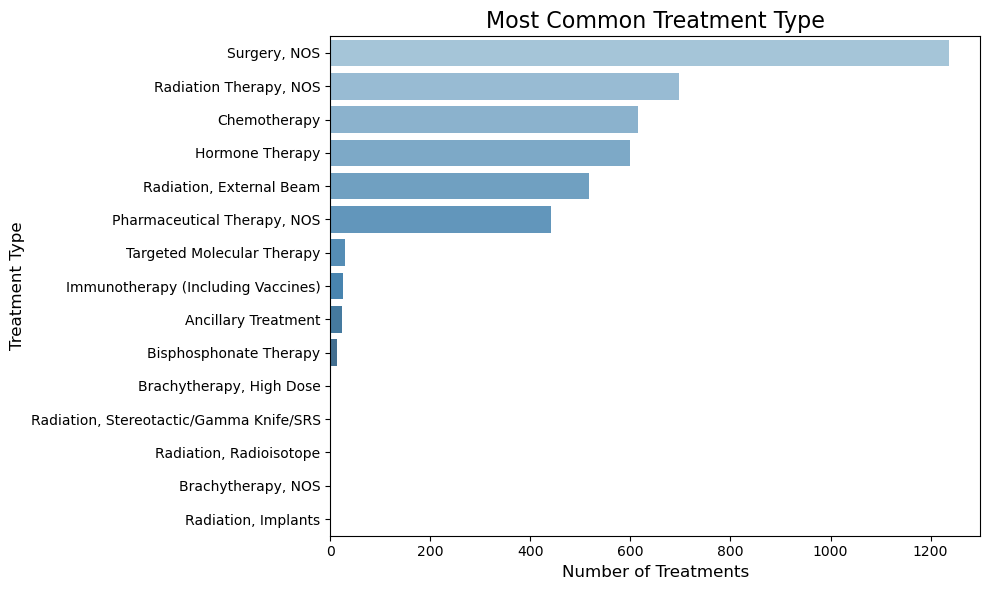

In [37]:
# Count how many times each treatment type appears
treatment_counts = df_treatments["treatments.treatment_type"].value_counts()

# Set figure size
plt.figure(figsize=(10,6))

# Draw a horizontal bar chart of treatment types
sns.barplot(
    x=treatment_counts.values,
    y=treatment_counts.index,
    hue=treatment_counts.index,
    palette="Blues_d",
    legend=False
)

plt.title("Most Common Treatment Type", fontsize=16)
plt.xlabel("Number of Treatments", fontsize=12)
plt.ylabel("Treatment Type", fontsize=12)

# Fix spacing so nothing gets cut off
plt.tight_layout()

plt.savefig('../images/treatment_types.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Calculate basic survival statistics for the whole dataset
print("Overall Patient Statistics:")
print("Total patients:", len(df_patients))
print("Alive patients:", df_patients["demographic.vital_status"].value_counts()["Alive"])
print("Dead patients:", df_patients["demographic.vital_status"].value_counts()["Dead"])
print("Average age:", round(df_patients["demographic.age_at_index"].mean(), 1))
print("Average survival days:", round(df_patients["survival_days"].mean(), 1))
print("---")

# Calculate survival statistics grouped by cancer stage
print("Average Survival Days by Cancer Stage:")
stage_survival = df_stage_survival.groupby(
    "diagnoses.ajcc_pathologic_stage"
)["survival_days"].mean().round(1)
print(stage_survival)

Overall Patient Statistics:
Total patients: 990
Alive patients: 883
Dead patients: 107
Average age: 58.5
Average survival days: 1189.0
---
Average Survival Days by Cancer Stage:
diagnoses.ajcc_pathologic_stage
Stage I       1786.3
Stage IA      1114.8
Stage IB      1449.7
Stage II      1726.0
Stage IIA     1133.4
Stage IIB     1203.3
Stage IIIA    1133.9
Stage IIIB     949.6
Stage IIIC     792.6
Stage IV       888.6
Name: survival_days, dtype: float64


In [39]:
# Create age groups for patients
bins = [0, 40, 50, 60, 70, 100]
labels = ["Under 40", "40-50", "50-60", "60-70", "Over 70"]

# Create a new column called age_group based on age_at_index
df_patients["age_group"] = pd.cut(
    df_patients["demographic.age_at_index"],
    bins=bins,
    labels=labels
)

# Calculate average survival days per age group
print("Average Survival Days by Age Group:")
age_survival = df_patients.groupby(
    "age_group", observed=True
)["survival_days"].mean().round(1)
print(age_survival)

Average Survival Days by Age Group:
age_group
Under 40    1439.1
40-50       1416.7
50-60       1202.3
60-70       1091.1
Over 70      932.1
Name: survival_days, dtype: float64


In [40]:
# Merge treatment type into patients table using case_id
df_merged = df_treatments.merge(
    df_patients[["cases.case_id", "survival_days"]],
    on = "cases.case_id",
    how = "left"
)

# Calculate average survival days per treatment type
print("Average Survival Days by Treatment Type:")
treatment_survival = df_merged.groupby(
    "treatments.treatment_type"
)["survival_days"].mean().round(2).sort_values(ascending=False)
print(treatment_survival)

Average Survival Days by Treatment Type:
treatments.treatment_type
Immunotherapy (Including Vaccines)         2043.09
Bisphosphonate Therapy                     1624.92
Targeted Molecular Therapy                 1446.37
Chemotherapy                               1259.97
Hormone Therapy                            1254.72
Pharmaceutical Therapy, NOS                1241.07
Radiation, Stereotactic/Gamma Knife/SRS    1229.00
Radiation, External Beam                   1216.97
Surgery, NOS                               1206.03
Radiation Therapy, NOS                     1203.52
Brachytherapy, High Dose                   1165.00
Ancillary Treatment                         647.60
Radiation, Radioisotope                     530.00
Brachytherapy, NOS                             NaN
Radiation, Implants                            NaN
Name: survival_days, dtype: float64


In [41]:
# Summary of key finding from our analysis
print("=" * 60)
print("KEY FINDINGS - TCGA Breast Cancer Clinical Analysis")
print("=" * 60)

print("\n1. DATASET OVERVIEW")
print("   Total patients analysed:", len(df_patients))
print("   Alive patients: 883 (89%)")
print("   Dead patients: 107 (11%)")
print("   Average patient age: 58.5 years")

print("\n2. CANCER STAGE FINDING")
print("   Stage I patients survived ~1786 days on average")
print("   Stage IIIC patients survived ~793 days on average")
print("   Earlier stage = significantly longer survival")

print("\n3. AGE GROUP FINDING")
print("   Under 40 patients survived ~1439 days on average")
print("   Over 70 patients survived ~932 days on average")
print("   Younger patients consistently survive longer")

print("\n4. TREATMENT FINDING")
print("   Immunotherapy showed highest survival: ~2043 days")
print("   Surgery most common treatment:", df_treatments["treatments.treatment_type"].value_counts()["Surgery, NOS"], "cases")
print("   Standard treatments show similar survival rates")

print("\n" + "=" * 60)
print("Analysis completed!")
print("=" * 60)

KEY FINDINGS - TCGA Breast Cancer Clinical Analysis

1. DATASET OVERVIEW
   Total patients analysed: 990
   Alive patients: 883 (89%)
   Dead patients: 107 (11%)
   Average patient age: 58.5 years

2. CANCER STAGE FINDING
   Stage I patients survived ~1786 days on average
   Stage IIIC patients survived ~793 days on average
   Earlier stage = significantly longer survival

3. AGE GROUP FINDING
   Under 40 patients survived ~1439 days on average
   Over 70 patients survived ~932 days on average
   Younger patients consistently survive longer

4. TREATMENT FINDING
   Immunotherapy showed highest survival: ~2043 days
   Surgery most common treatment: 1237 cases
   Standard treatments show similar survival rates

Analysis completed!
